In [1]:
import pandas as pd
import numpy as np

athletes = pd.read_csv('athlete_events.csv')
regions = pd.read_csv('noc_regions.csv')

print(athletes.shape)
print(athletes.head())

(271116, 15)
   ID                      Name Sex   Age  Height  Weight            Team  \
0   1                 A Dijiang   M  24.0   180.0    80.0           China   
1   2                  A Lamusi   M  23.0   170.0    60.0           China   
2   3       Gunnar Nielsen Aaby   M  24.0     NaN     NaN         Denmark   
3   4      Edgar Lindenau Aabye   M  34.0     NaN     NaN  Denmark/Sweden   
4   5  Christine Jacoba Aaftink   F  21.0   185.0    82.0     Netherlands   

   NOC        Games  Year  Season       City          Sport  \
0  CHN  1992 Summer  1992  Summer  Barcelona     Basketball   
1  CHN  2012 Summer  2012  Summer     London           Judo   
2  DEN  1920 Summer  1920  Summer  Antwerpen       Football   
3  DEN  1900 Summer  1900  Summer      Paris     Tug-Of-War   
4  NED  1988 Winter  1988  Winter    Calgary  Speed Skating   

                              Event Medal  
0       Basketball Men's Basketball   NaN  
1      Judo Men's Extra-Lightweight   NaN  
2           F

In [2]:
df = athletes.merge(regions, on='NOC', how='left')

df['Medal'] = df['Medal'].fillna('No Medal')

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Height'] = df['Height'].fillna(df['Height'].median())
df['Weight'] = df['Weight'].fillna(df['Weight'].median())

print("Shape:", df.shape)
print("Missing values left:")
print(df.isnull().sum())
print("\nFirst row:")
print(df.head(1))

Shape: (271116, 17)
Missing values left:
ID             0
Name           0
Sex            0
Age            0
Height         0
Weight         0
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal          0
region       370
notes     266077
dtype: int64

First row:
   ID       Name Sex   Age  Height  Weight   Team  NOC        Games  Year  \
0   1  A Dijiang   M  24.0   180.0    80.0  China  CHN  1992 Summer  1992   

   Season       City       Sport                        Event     Medal  \
0  Summer  Barcelona  Basketball  Basketball Men's Basketball  No Medal   

  region notes  
0  China   NaN  


In [3]:
# Drop the 'notes' column, we don't need it
df = df.drop(columns=['notes'])

# Fill missing region with Team name (backup)
df['region'] = df['region'].fillna(df['Team'])

# Confirm all clean
print("Missing values:")
print(df.isnull().sum())
print("\nShape:", df.shape)
print("\nColumns we have:", list(df.columns))

Missing values:
ID        0
Name      0
Sex       0
Age       0
Height    0
Weight    0
Team      0
NOC       0
Games     0
Year      0
Season    0
City      0
Sport     0
Event     0
Medal     0
region    0
dtype: int64

Shape: (271116, 16)

Columns we have: ['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal', 'region']


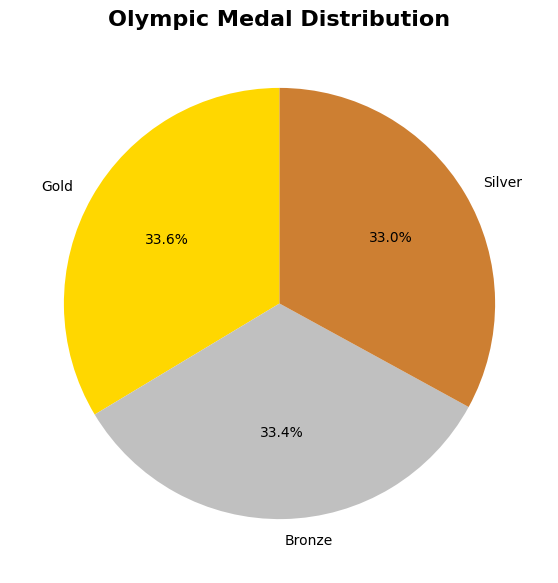

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

medal_counts = df[df['Medal'] != 'No Medal']['Medal'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(medal_counts, labels=medal_counts.index, autopct='%1.1f%%', 
        colors=['gold', 'silver', '#cd7f32'], startangle=90)
plt.title('Olympic Medal Distribution', fontsize=16, fontweight='bold')
plt.show()

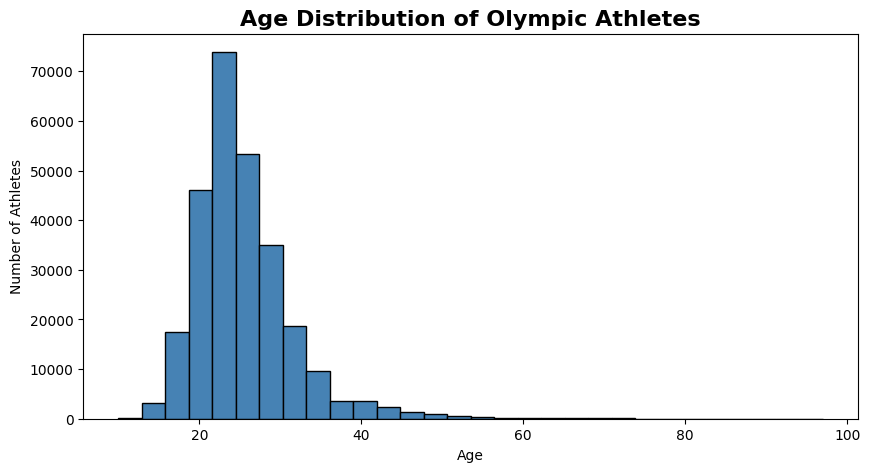

In [6]:
plt.figure(figsize=(10,5))
plt.hist(df['Age'], bins=30, color='steelblue', edgecolor='black')
plt.title('Age Distribution of Olympic Athletes', fontsize=16, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Number of Athletes')
plt.show()

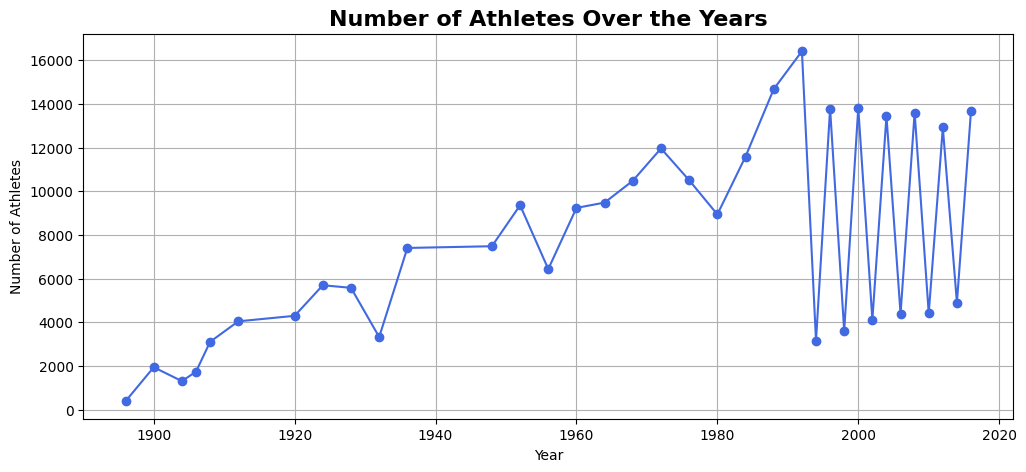

In [7]:
athletes_per_year = df.groupby('Year')['Name'].count()

plt.figure(figsize=(12,5))
plt.plot(athletes_per_year.index, athletes_per_year.values, marker='o', color='royalblue')
plt.title('Number of Athletes Over the Years', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Athletes')
plt.grid(True)
plt.show()

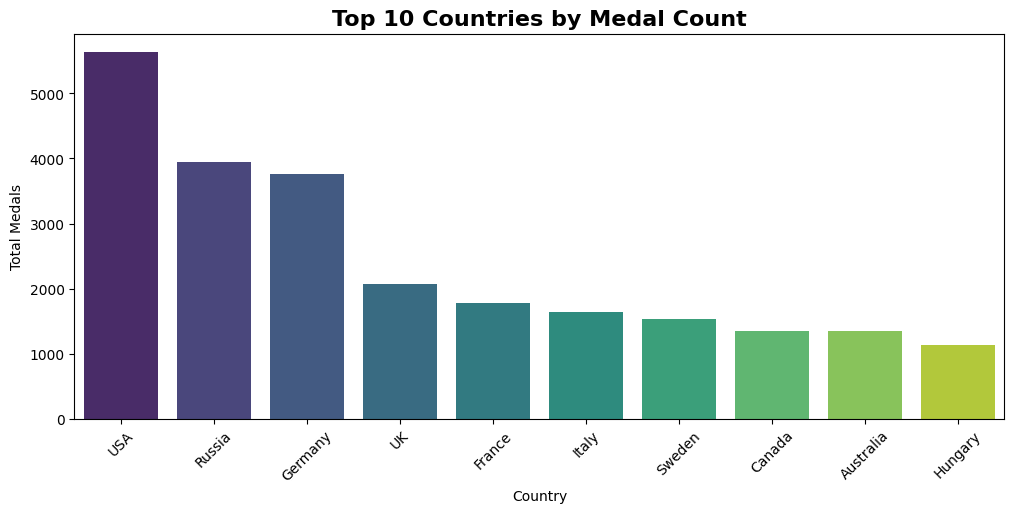

In [9]:
top_countries = df[df['Medal']!='No Medal']['region'].value_counts().head(10).reset_index()
top_countries.columns = ['region', 'count']

plt.figure(figsize=(12,5))
sns.barplot(data=top_countries, x='region', y='count', hue='region', palette='viridis', legend=False)
plt.title('Top 10 Countries by Medal Count', fontsize=16, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Total Medals')
plt.xticks(rotation=45)
plt.show()

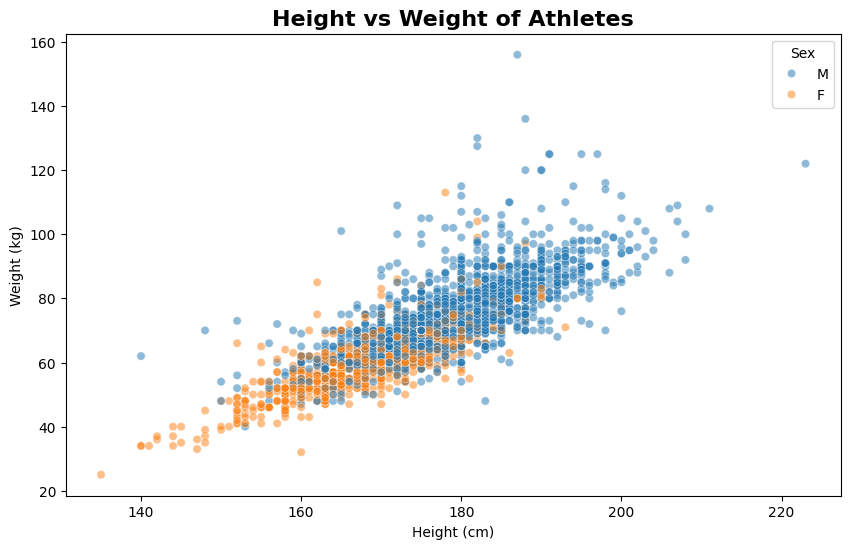

In [10]:
sample = df.sample(3000, random_state=42)

plt.figure(figsize=(10,6))
sns.scatterplot(data=sample, x='Height', y='Weight', hue='Sex', alpha=0.5)
plt.title('Height vs Weight of Athletes', fontsize=16, fontweight='bold')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

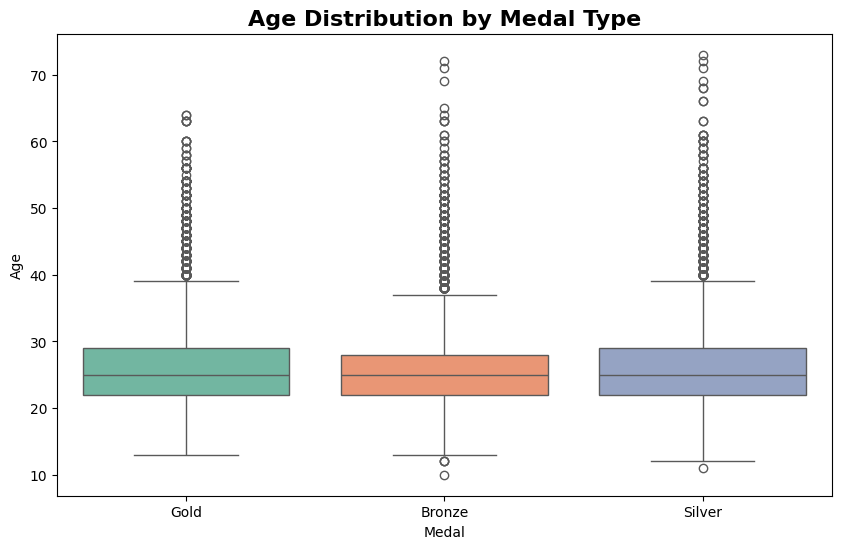

In [12]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[df['Medal']!='No Medal'], x='Medal', y='Age', 
            hue='Medal', palette='Set2', legend=False)
plt.title('Age Distribution by Medal Type', fontsize=16, fontweight='bold')
plt.xlabel('Medal')
plt.ylabel('Age')
plt.show()

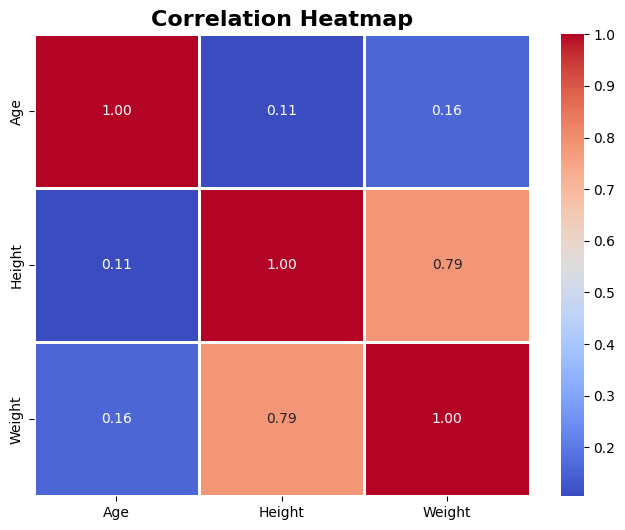

In [13]:
plt.figure(figsize=(8,6))
corr = df[['Age','Height','Weight']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.show()

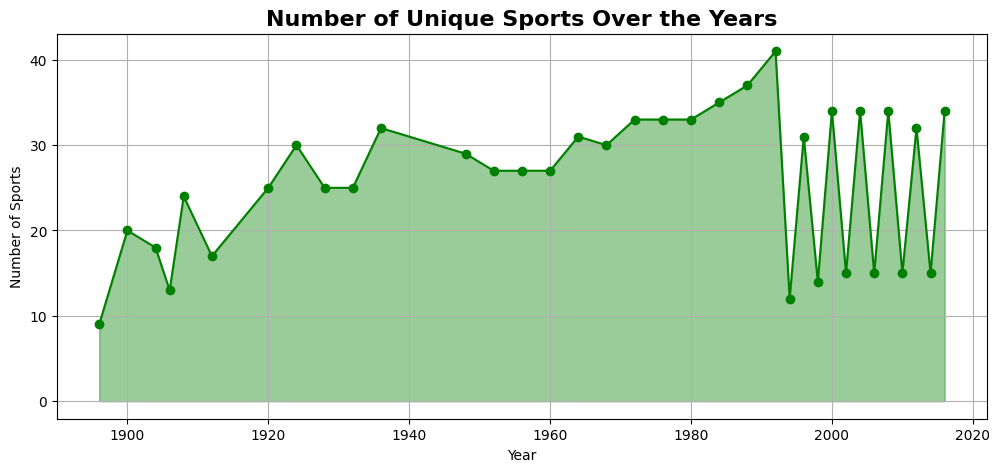

In [14]:
sports_per_year = df.groupby('Year')['Sport'].nunique()

plt.figure(figsize=(12,5))
plt.fill_between(sports_per_year.index, sports_per_year.values, alpha=0.4, color='green')
plt.plot(sports_per_year.index, sports_per_year.values, color='green', marker='o')
plt.title('Number of Unique Sports Over the Years', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Sports')
plt.grid(True)
plt.show()

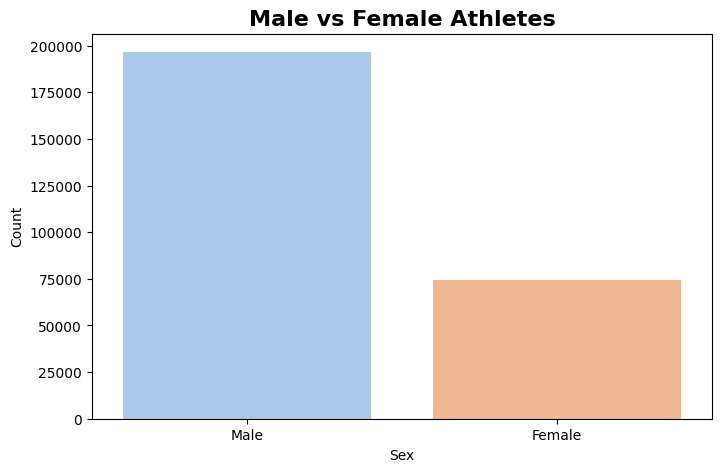

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Sex', hue='Sex', palette='pastel', legend=False)
plt.title('Male vs Female Athletes', fontsize=16, fontweight='bold')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.xticks([0,1], ['Male', 'Female'])
plt.show()

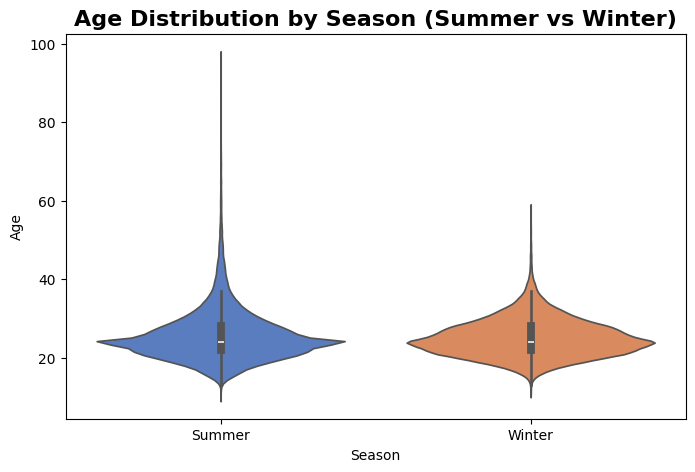

In [16]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x='Season', y='Age', 
               hue='Season', palette='muted', legend=False)
plt.title('Age Distribution by Season (Summer vs Winter)', fontsize=16, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Age')
plt.show()